In [1]:
from pathlib import Path

import pandas as pd

DATA_PATH = Path("../data/raw/ai4i2020.csv")

df = pd.read_csv(DATA_PATH)

df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [2]:
df.shape

(10000, 14)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

In [4]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
UDI,10000.0,NaN,NaN,NaN,5000.5,2886.89568,1.0,2500.75,5000.5,7500.25,10000.0
Product ID,10000,10000,L57163,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Type,10000,3,L,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Air temperature [K],10000.0,NaN,NaN,NaN,300.00493,2.000259,295.3,298.3,300.1,301.5,304.5
Process temperature [K],10000.0,NaN,NaN,NaN,310.00556,1.483734,305.7,308.8,310.1,311.1,313.8
Rotational speed [rpm],10000.0,NaN,NaN,NaN,1538.7761,179.284096,1168.0,1423.0,1503.0,1612.0,2886.0
Torque [Nm],10000.0,NaN,NaN,NaN,39.98691,9.968934,3.8,33.2,40.1,46.8,76.6
Tool wear [min],10000.0,NaN,NaN,NaN,107.951,63.654147,0.0,53.0,108.0,162.0,253.0
Machine failure,10000.0,NaN,NaN,NaN,0.0339,0.180981,0.0,0.0,0.0,0.0,1.0
TWF,10000.0,NaN,NaN,NaN,0.0046,0.067671,0.0,0.0,0.0,0.0,1.0


In [5]:
df.isna().sum()

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.nunique()

UDI                        10000
Product ID                 10000
Type                           3
Air temperature [K]           93
Process temperature [K]       82
Rotational speed [rpm]       941
Torque [Nm]                  577
Tool wear [min]              246
Machine failure                2
TWF                            2
HDF                            2
PWF                            2
OSF                            2
RNF                            2
dtype: int64

In [8]:
df["Machine failure"].value_counts()

Machine failure
0    9661
1     339
Name: count, dtype: int64

In [9]:
df["Machine failure"].value_counts(normalize=True)

Machine failure
0    0.9661
1    0.0339
Name: proportion, dtype: float64

In [10]:
failure_cols = [
    "TWF",
    "HDF",
    "PWF",
    "OSF",
    "RNF",
]

df[failure_cols].sum().sort_values(ascending=False)

HDF    115
OSF     98
PWF     95
TWF     46
RNF     19
dtype: int64

## 初期データ確認

- データセットは10,000行、14列で構成されている。
- 欠損値および完全重複データは存在しない。
- Product IDは全10,000件で一意であり、識別子としての性質が強い。
- 目的変数 Machine failure は、正常が9,661件（96.61%）、故障が339件（3.39%）である。
- 正常データが大多数を占めており、強いクラス不均衡が存在する。
- そのため、モデル評価ではAccuracyだけでなく、Recall、Precision、F1、PR-AUCなどを確認する必要がある。

In [11]:
failure_summary = (
    df[failure_cols]
    .sum()
    .sort_values(ascending=False)
    .rename("count")
    .to_frame()
)

failure_summary["percentage"] = (
    failure_summary["count"] / len(df) * 100
)

failure_summary

,count,percentage
HDF,115,1.15
OSF,98,0.98
PWF,95,0.95
TWF,46,0.46
RNF,19,0.19


In [12]:
df["failure_type_count"] = df[failure_cols].sum(axis=1)

df["failure_type_count"].value_counts().sort_index()

failure_type_count
0    9652
1     324
2      23
3       1
Name: count, dtype: int64

In [13]:
df.loc[
    df["failure_type_count"] >= 2,
    ["Machine failure", *failure_cols]
].head(10)

,Machine failure,TWF,HDF,PWF,OSF,RNF
69,1,0,0,1,1,0
1324,1,0,0,1,1,0
1496,1,0,0,1,1,0
3611,1,1,0,0,0,1
3854,1,0,0,1,1,0
3943,1,0,0,1,1,0
4254,1,0,1,1,0,0
4342,1,0,1,1,0,0
4370,1,0,1,0,1,0
4383,1,0,1,0,1,0


In [14]:
pd.crosstab(
    df["Machine failure"],
    df["failure_type_count"]
)

failure_type_count,0,1,2,3
Machine failure,,,,
0,9643,18,0,0
1,9,306,23,1


### 故障ラベルの整合性確認

5種類の故障タイプを合計した結果、複数の故障タイプが同時に発生しているデータが確認された。

- 故障タイプ1種類：324件
- 故障タイプ2種類：23件
- 故障タイプ3種類：1件

また、Machine failureと各故障タイプの整合性を確認したところ、
以下の不一致が存在した。

- Machine failure = 1 かつ故障タイプ数 = 0：9件
- Machine failure = 0 かつ故障タイプ数 = 1：18件

UCIのデータセット説明では、5種類の故障モードのうち少なくとも1つが発生した場合に
Machine failure = 1になると説明されているが、実データには説明と一致しないケースが存在する。

本分析ではこれらを恣意的に修正・削除せず、元データのMachine failureを目的変数として使用する。

なお、TWF・HDF・PWF・OSF・RNFおよびfailure_type_countは目的変数と直接関係するため、
Machine failureを予測するモデルの説明変数には使用しない。

In [15]:
type_summary = (
    df["Type"]
    .value_counts()
    .rename("count")
    .to_frame()
)

type_summary["percentage"] = (
    type_summary["count"] / len(df) * 100
)

type_summary

,count,percentage
Type,,
L,6000,60.00
M,2997,29.97
H,1003,10.03


In [16]:
type_failure = (
    df.groupby("Type")["Machine failure"]
    .agg(["count", "sum", "mean"])
)

type_failure = type_failure.rename(
    columns={
        "count": "total",
        "sum": "failures",
        "mean": "failure_rate",
    }
)

type_failure["failure_rate"] *= 100

type_failure

,total,failures,failure_rate
Type,,,
H,1003,21,2.093719
L,6000,235,3.916667
M,2997,83,2.769436


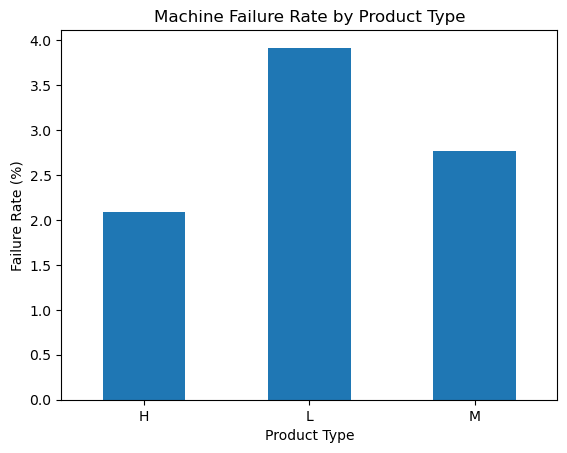

In [17]:
import matplotlib.pyplot as plt

type_failure["failure_rate"].plot(kind="bar")

plt.title("Machine Failure Rate by Product Type")
plt.xlabel("Product Type")
plt.ylabel("Failure Rate (%)")
plt.xticks(rotation=0)
plt.show()

### Product Typeと故障率

製品Type別に故障率を比較したところ、以下の違いが確認された。

- L：3.92%
- M：2.77%
- H：2.09%

Lタイプの故障率が最も高く、Hタイプが最も低かった。
この結果から、Product Typeと機械故障の発生には関連がある可能性が考えられる。

ただし、この集計だけではTypeそのものが故障の原因であるとは判断できない。
他の特徴量との関係も確認したうえで、故障との関連を検討する。

In [18]:
numeric_features = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]",
]

In [19]:
failure_numeric_summary = (
    df.groupby("Machine failure")[numeric_features]
    .agg(["mean", "median"])
    .T
)

failure_numeric_summary

Machine failure                           0            1
Air temperature [K]     mean     299.973999   300.886431
                        median   300.000000   301.600000
Process temperature [K] mean     309.995570   310.290265
                        median   310.000000   310.400000
Rotational speed [rpm]  mean    1540.260014  1496.486726
                        median  1507.000000  1365.000000
Torque [Nm]             mean      39.629655    50.168142
                        median    39.900000    53.700000
Tool wear [min]         mean     106.693717   143.781711
                        median   107.000000   165.000000

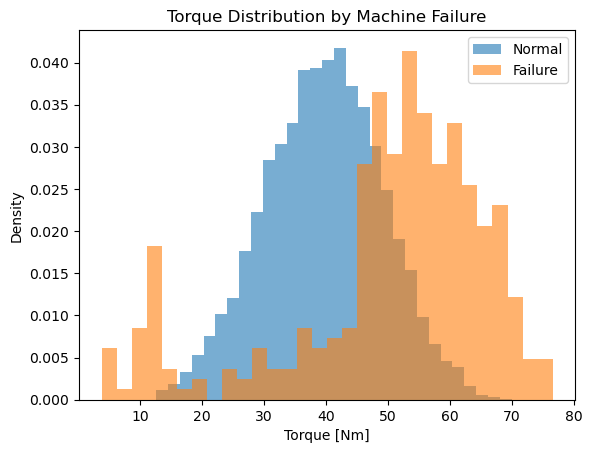

In [20]:
failure_data = df[df["Machine failure"] == 1]
normal_data = df[df["Machine failure"] == 0]

plt.hist(
    normal_data["Torque [Nm]"],
    bins=30,
    alpha=0.6,
    density=True,
    label="Normal",
)

plt.hist(
    failure_data["Torque [Nm]"],
    bins=30,
    alpha=0.6,
    density=True,
    label="Failure",
)

plt.title("Torque Distribution by Machine Failure")
plt.xlabel("Torque [Nm]")
plt.ylabel("Density")
plt.legend()
plt.show()

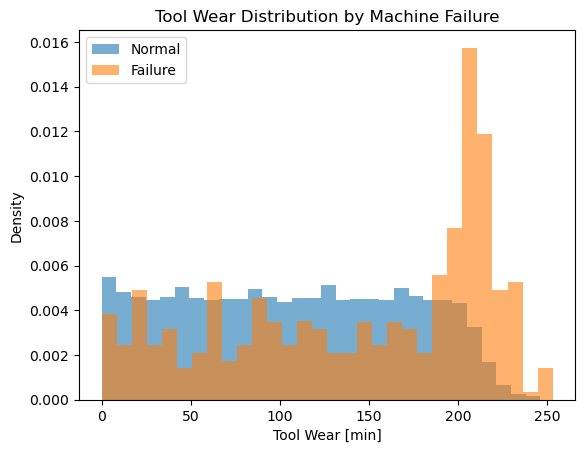

In [21]:
plt.hist(
    normal_data["Tool wear [min]"],
    bins=30,
    alpha=0.6,
    density=True,
    label="Normal",
)

plt.hist(
    failure_data["Tool wear [min]"],
    bins=30,
    alpha=0.6,
    density=True,
    label="Failure",
)

plt.title("Tool Wear Distribution by Machine Failure")
plt.xlabel("Tool Wear [min]")
plt.ylabel("Density")
plt.legend()
plt.show()

### 正常データと故障データの数値特徴量比較

正常データと故障データの数値特徴量を比較したところ、特にTorqueとTool wearに違いが確認された。

- Torqueの平均値は正常時39.63 Nmに対して、故障時50.17 Nmだった。
- Torqueの中央値も正常時39.9 Nmに対して、故障時53.7 Nmだった。
- Tool wearの平均値は正常時106.69 minに対して、故障時143.78 minだった。
- Tool wearの中央値は正常時107 minに対して、故障時165 minだった。
- Rotational speedの中央値は正常時1507 rpmに対して、故障時1365 rpmと低かった。
- Air temperatureも故障データの方がやや高い傾向が確認された。

以上から、Torque、Tool wear、Rotational speedなどが故障と関連している可能性が考えられる。

ただし、これらの特徴量が単独で故障を引き起こしているとは判断できない。
故障条件には複数の特徴量の組み合わせが関係している可能性があるため、今後は特徴量間の関係も分析する。

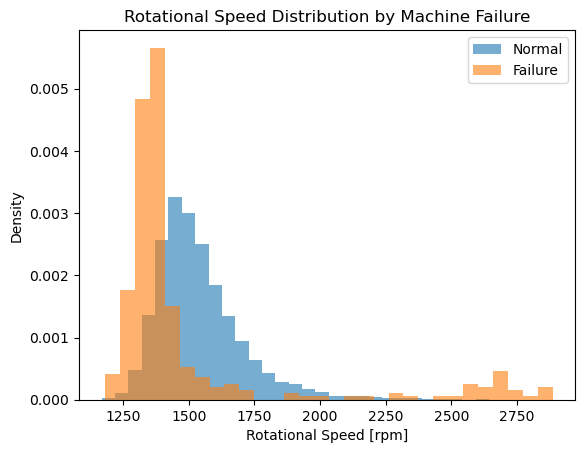

In [22]:
plt.hist(
    normal_data["Rotational speed [rpm]"],
    bins=30,
    alpha=0.6,
    density=True,
    label="Normal",
)

plt.hist(
    failure_data["Rotational speed [rpm]"],
    bins=30,
    alpha=0.6,
    density=True,
    label="Failure",
)

plt.title("Rotational Speed Distribution by Machine Failure")
plt.xlabel("Rotational Speed [rpm]")
plt.ylabel("Density")
plt.legend()
plt.show()

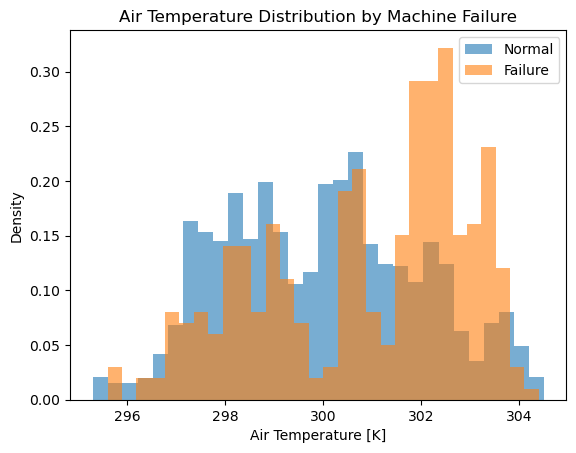

In [23]:
plt.hist(
    normal_data["Air temperature [K]"],
    bins=30,
    alpha=0.6,
    density=True,
    label="Normal",
)

plt.hist(
    failure_data["Air temperature [K]"],
    bins=30,
    alpha=0.6,
    density=True,
    label="Failure",
)

plt.title("Air Temperature Distribution by Machine Failure")
plt.xlabel("Air Temperature [K]")
plt.ylabel("Density")
plt.legend()
plt.show()

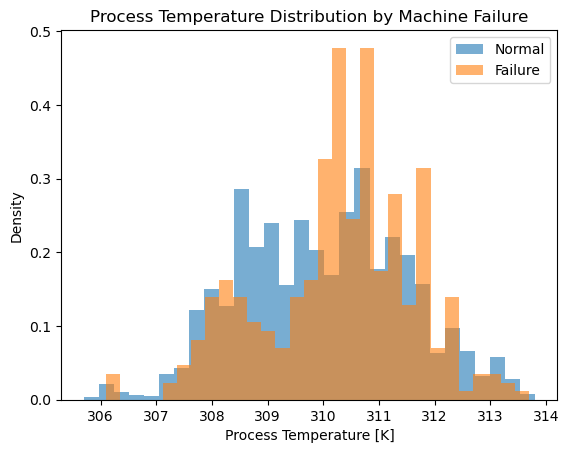

In [24]:
plt.hist(
    normal_data["Process temperature [K]"],
    bins=30,
    alpha=0.6,
    density=True,
    label="Normal",
)

plt.hist(
    failure_data["Process temperature [K]"],
    bins=30,
    alpha=0.6,
    density=True,
    label="Failure",
)

plt.title("Process Temperature Distribution by Machine Failure")
plt.xlabel("Process Temperature [K]")
plt.ylabel("Density")
plt.legend()
plt.show()

### 数値特徴量の分布から得られた傾向

正常データと故障データの分布を比較した結果、以下の傾向が確認された。

- Rotational speedは、故障データでは正常データより低い回転数の領域に多く分布している。
- Air temperatureは、故障データの方が比較的高い温度領域に分布する傾向が見られる。
- Process temperatureでは、正常データと故障データの分布に大きな違いは確認しにくい。
- TorqueとTool wearについては、故障データで高い値を取る傾向が確認された。

一方、各特徴量の分布には正常データと故障データの重なりも多く、
単一の特徴量だけで故障を判別することは難しいと考えられる。

そこで次に、故障メカニズムに関係すると考えられる複数特徴量の組み合わせを分析する。

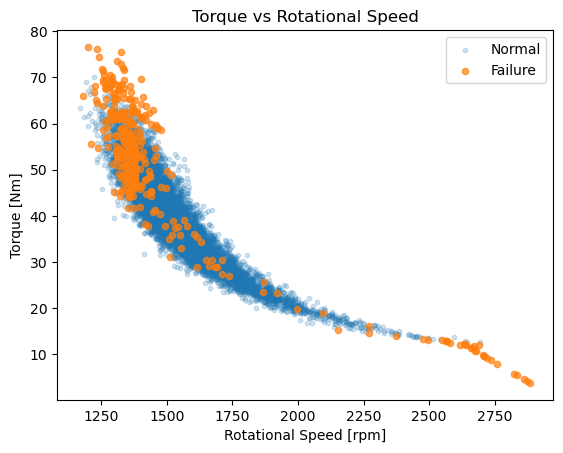

In [25]:
plt.scatter(
    normal_data["Rotational speed [rpm]"],
    normal_data["Torque [Nm]"],
    alpha=0.2,
    s=10,
    label="Normal",
)

plt.scatter(
    failure_data["Rotational speed [rpm]"],
    failure_data["Torque [Nm]"],
    alpha=0.7,
    s=20,
    label="Failure",
)

plt.title("Torque vs Rotational Speed")
plt.xlabel("Rotational Speed [rpm]")
plt.ylabel("Torque [Nm]")
plt.legend()
plt.show()

In [26]:
import numpy as np

df["Power [W]"] = (
    df["Torque [Nm]"]
    * df["Rotational speed [rpm]"]
    * 2
    * np.pi
    / 60
)

In [27]:
df.groupby("Machine failure")["Power [W]"].agg(
    ["mean", "median", "min", "max"]
)

,mean,median,min,max
Machine failure,,,,
0,6244.547534,6243.046225,3515.033772,8998.024015
1,7282.819485,7611.429737,1148.440610,10469.923005


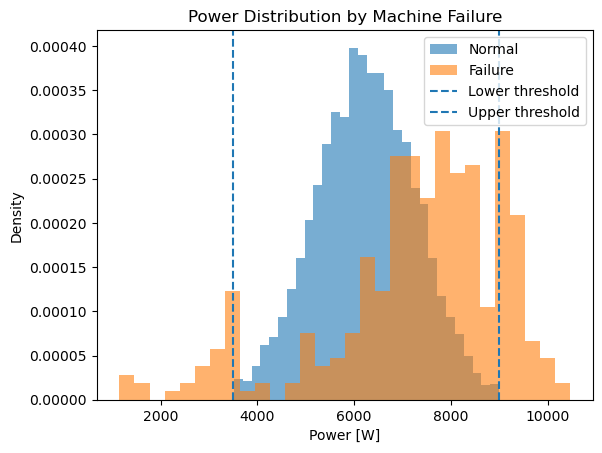

In [28]:
plt.hist(
    df.loc[df["Machine failure"] == 0, "Power [W]"],
    bins=30,
    alpha=0.6,
    density=True,
    label="Normal",
)

plt.hist(
    df.loc[df["Machine failure"] == 1, "Power [W]"],
    bins=30,
    alpha=0.6,
    density=True,
    label="Failure",
)

plt.axvline(3500, linestyle="--", label="Lower threshold")
plt.axvline(9000, linestyle="--", label="Upper threshold")

plt.title("Power Distribution by Machine Failure")
plt.xlabel("Power [W]")
plt.ylabel("Density")
plt.legend()
plt.show()

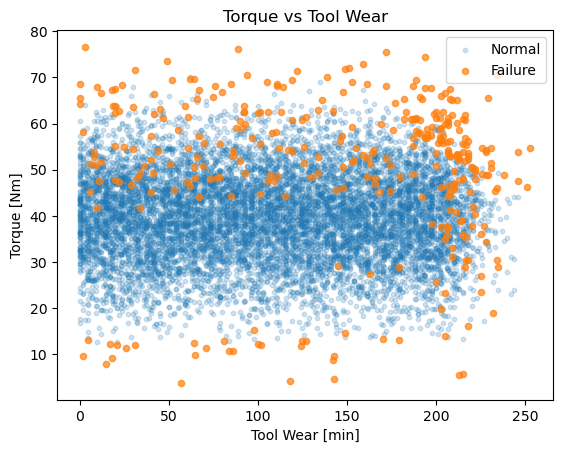

In [29]:
plt.scatter(
    normal_data["Tool wear [min]"],
    normal_data["Torque [Nm]"],
    alpha=0.2,
    s=10,
    label="Normal",
)

plt.scatter(
    failure_data["Tool wear [min]"],
    failure_data["Torque [Nm]"],
    alpha=0.7,
    s=20,
    label="Failure",
)

plt.title("Torque vs Tool Wear")
plt.xlabel("Tool Wear [min]")
plt.ylabel("Torque [Nm]")
plt.legend()
plt.show()

In [30]:
df["Wear-Torque"] = (
    df["Tool wear [min]"]
    * df["Torque [Nm]"]
)

df.groupby("Machine failure")["Wear-Torque"].agg(
    ["mean", "median", "min", "max"]
)

,mean,median,min,max
Machine failure,,,,
0,4213.842708,3952.8,0.0,11919.8
1,7187.938348,7681.8,0.0,16497.0


In [31]:
df["Temperature difference [K]"] = (
    df["Process temperature [K]"]
    - df["Air temperature [K]"]
)

In [32]:
df.groupby("Machine failure")[
    "Temperature difference [K]"
].agg(["mean", "median", "min", "max"])

,mean,median,min,max
Machine failure,,,,
0,10.021571,9.8,7.6,12.1
1,9.403835,9.3,7.6,12.0


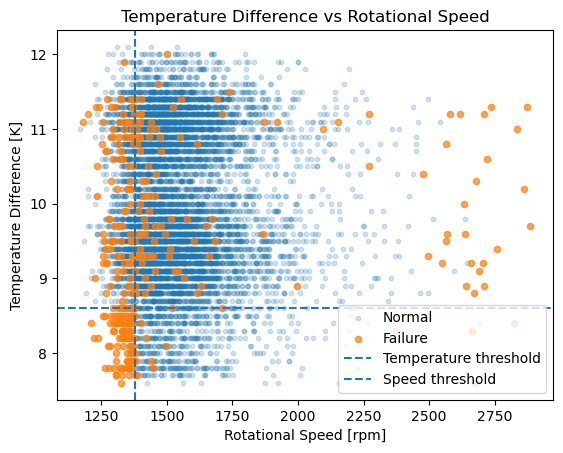

In [33]:
plt.scatter(
    df.loc[df["Machine failure"] == 0, "Rotational speed [rpm]"],
    df.loc[df["Machine failure"] == 0, "Temperature difference [K]"],
    alpha=0.2,
    s=10,
    label="Normal",
)

plt.scatter(
    df.loc[df["Machine failure"] == 1, "Rotational speed [rpm]"],
    df.loc[df["Machine failure"] == 1, "Temperature difference [K]"],
    alpha=0.7,
    s=20,
    label="Failure",
)

plt.axhline(8.6, linestyle="--", label="Temperature threshold")
plt.axvline(1380, linestyle="--", label="Speed threshold")

plt.title("Temperature Difference vs Rotational Speed")
plt.xlabel("Rotational Speed [rpm]")
plt.ylabel("Temperature Difference [K]")
plt.legend()
plt.show()

### 故障メカニズムを考慮した派生特徴量の分析

単一のセンサー値だけでなく、AI4I 2020の故障メカニズムを参考に、
Power、Wear-Torque、Temperature differenceの3つの派生特徴量を分析した。

#### Power

正常データのPowerは約3,515～8,998 Wの範囲だったのに対し、
故障データでは約1,148～10,470 Wまで広がっていた。

特に低Power・高Power領域に故障データが存在しており、
TorqueとRotational speedを組み合わせることで、
単独の特徴量では捉えにくかった故障パターンを表現できる可能性がある。

#### Wear-Torque

Wear-Torqueの中央値は正常時3,952.8に対して、
故障時7,681.8と高かった。

工具摩耗とTorqueを組み合わせることで、
設備に加わる負荷と故障の関係を表現できる可能性がある。

ただし、故障データにもWear-Torqueが低いケースが存在するため、
この特徴量だけですべての故障を説明することはできない。

#### Temperature difference

Process temperatureとAir temperatureの差は、
正常時の平均10.02 Kに対して故障時9.40 Kだった。

故障データでは温度差がやや小さい傾向が確認されたが、
正常データとの重なりも大きい。

そのため、Temperature difference単独ではなく、
Rotational speedなど他の特徴量との組み合わせが重要であると考えられる。

### EDAから得られた示唆

今回の分析から、設備故障は単一のセンサー値だけではなく、
複数のセンサー値や設備状態の組み合わせによって特徴付けられる可能性が示された。

今後の予測モデルでは元のセンサー特徴量に加えて、
これらの派生特徴量を利用した場合の予測性能も比較する。

In [34]:
correlation_features = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]",
    "Power [W]",
    "Wear-Torque",
    "Temperature difference [K]",
    "Machine failure",
]

correlation_matrix = df[correlation_features].corr()

correlation_matrix

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Power [W],Wear-Torque,Temperature difference [K],Machine failure
Air temperature [K],1.000000,0.876107,0.022670,-0.013778,0.013853,-0.011474,0.006981,-0.699583,0.082556
Process temperature [K],0.876107,1.000000,0.019277,-0.014061,0.013488,-0.010952,0.006003,-0.268413,0.035946
Rotational speed [rpm],0.022670,0.019277,1.000000,-0.875027,0.000223,-0.805584,-0.331277,-0.016727,-0.044188
Torque [Nm],-0.013778,-0.014061,-0.875027,1.000000,-0.003093,0.978828,0.377038,0.006690,0.191321
Tool wear [min],0.013853,0.013488,0.000223,-0.003093,1.000000,-0.003193,0.897520,-0.007689,0.105448
Power [W],-0.011474,-0.010952,-0.805584,0.978828,-0.003193,1.000000,0.368842,0.006694,0.176039
Wear-Torque,0.006981,0.006003,-0.331277,0.377038,0.897520,0.368842,1.000000,-0.005051,0.190427
Temperature difference [K],-0.699583,-0.268413,-0.016727,0.006690,-0.007689,0.006694,-0.005051,1.000000,-0.111676
Machine failure,0.082556,0.035946,-0.044188,0.191321,0.105448,0.176039,0.190427,-0.111676,1.000000


In [35]:
failure_correlation = (
    correlation_matrix["Machine failure"]
    .drop("Machine failure")
    .sort_values(key=abs, ascending=False)
)

failure_correlation

Torque [Nm]                   0.191321
Wear-Torque                   0.190427
Power [W]                     0.176039
Temperature difference [K]   -0.111676
Tool wear [min]               0.105448
Air temperature [K]           0.082556
Rotational speed [rpm]       -0.044188
Process temperature [K]       0.035946
Name: Machine failure, dtype: float64

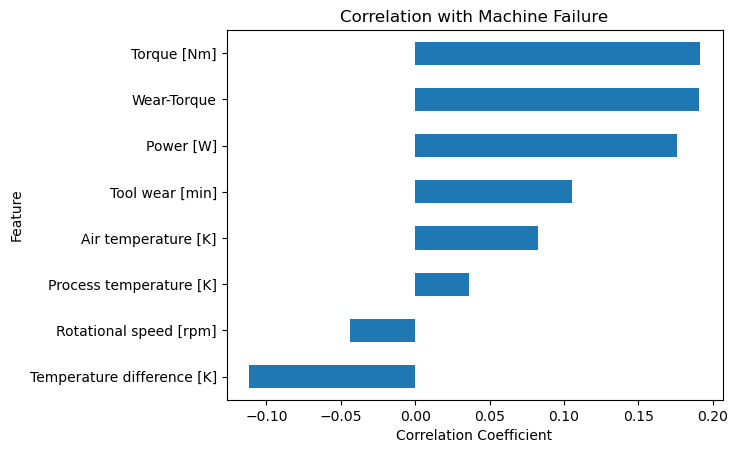

In [36]:
failure_correlation.sort_values().plot(kind="barh")

plt.title("Correlation with Machine Failure")
plt.xlabel("Correlation Coefficient")
plt.ylabel("Feature")
plt.show()

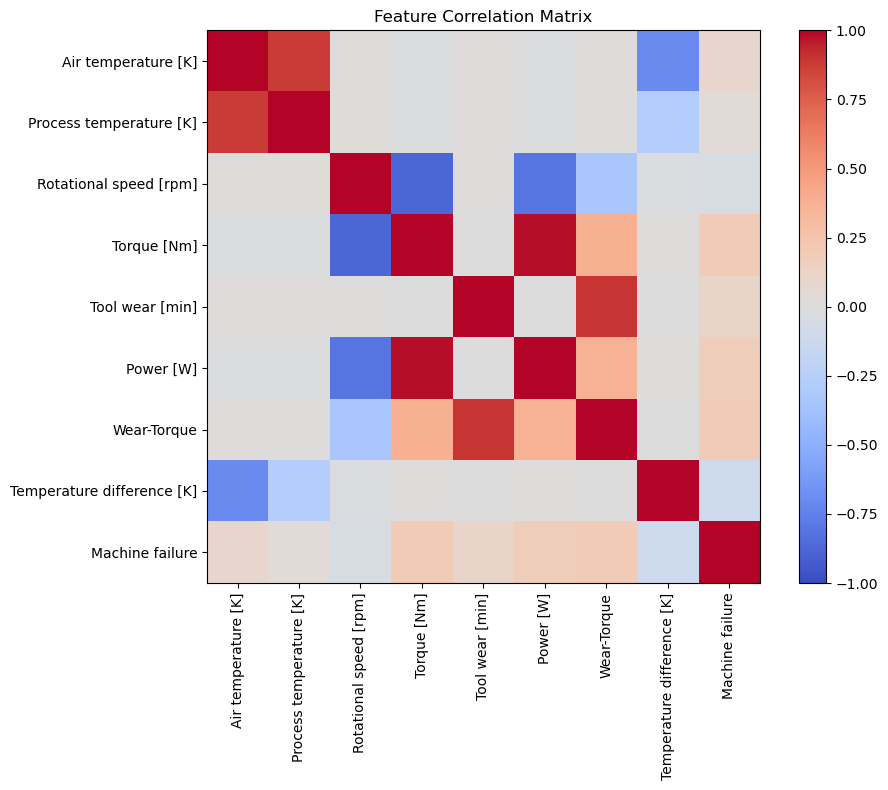

In [37]:
fig, ax = plt.subplots(figsize=(10, 8))

image = ax.imshow(
    correlation_matrix,
    vmin=-1,
    vmax=1,
    cmap="coolwarm",
)

ax.set_xticks(range(len(correlation_features)))
ax.set_yticks(range(len(correlation_features)))

ax.set_xticklabels(
    correlation_features,
    rotation=90,
)

ax.set_yticklabels(correlation_features)

fig.colorbar(image)

plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

### 相関分析から得られた示唆

Machine failureとのPearson相関係数を確認したところ、
最も相関が大きかった特徴量はTorque（0.191）だった。

続いて、Wear-Torque（0.190）、Power（0.176）、
Temperature difference（-0.112）、Tool wear（0.105）となった。

いずれの特徴量もMachine failureとの強い線形相関は確認されなかった。
そのため、単一特徴量の線形関係だけで設備故障を説明することは難しいと考えられる。

一方、特徴量同士では以下のような強い相関が確認された。

- Air temperatureとProcess temperature：約0.88
- Rotational speedとTorque：約-0.88
- TorqueとPower：約0.98
- Rotational speedとPower：約-0.81

特にPowerはTorqueとRotational speedから計算した派生特徴量であるため、
元特徴量との強い相関が存在する。

また、Power Failureのように値が低すぎる場合と高すぎる場合の両方で
故障リスクが高まる非線形な関係は、Pearson相関係数だけでは十分に捉えられない。

今後のモデル構築では、単純な線形関係だけでなく、
特徴量間の相互作用や非線形関係を学習できるモデルについても比較する。

## EDAから得られた仮説

EDAから、以下の仮説を設定した。

1. Torqueが高い設備では故障リスクが高くなる可能性がある。
2. Tool wearが進んだ設備では故障リスクが高くなる可能性がある。
3. Rotational speedとTorqueの組み合わせが故障予測に重要である可能性がある。
4. Tool wearとTorqueの組み合わせが故障予測に重要である可能性がある。
5. 温度差とRotational speedの組み合わせが故障予測に重要である可能性がある。
6. Product Typeによって故障率に違いがあり、Typeも予測に有効である可能性がある。
7. 単一特徴量との線形相関は弱いため、特徴量間の相互作用や非線形関係を扱えるモデルが有効である可能性がある。

これらの仮説について、次のモデル構築フェーズで検証する。

## 次のステップ

次のフェーズでは、Machine failureを目的変数とした
二値分類モデルを構築する。

まず元のセンサー特徴量を使用したベースラインモデルを構築し、
その後、EDAで作成した派生特徴量を追加したモデルと性能を比較する。

Machine failureは全体の約3.39%とクラス不均衡が大きいため、
Accuracyだけではなく、Precision、Recall、F1、ROC-AUC、
PR-AUCなどを用いて評価する。

特に予知保全では故障設備の見逃しが重要な問題になるため、
Recallを重視しながらPrecisionとのバランスを評価する。